In [1]:
%matplotlib inline
import cv2
import numpy as np
from matplotlib import pyplot as plt

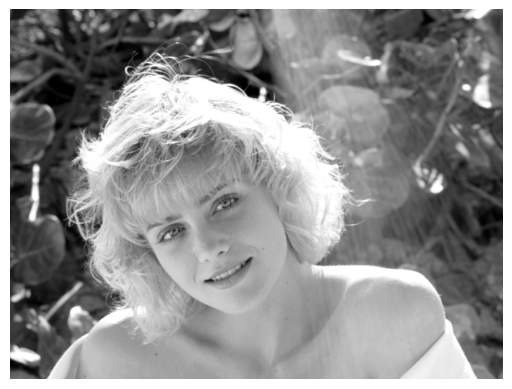

In [2]:
# Carregar a imagem em modo grayscale
imagem = cv2.imread('images/pgm_bin/marcie.pgm', cv2.IMREAD_GRAYSCALE)

# Exibindo imagem
plt.imshow(imagem, cmap='gray')
plt.axis('off') 
plt.show()

# Função de predição e sua inversa

In [3]:
def previous(x, y, img):
    if (x == 0):
        return img[y, x]
    return  img[y, x] - img[y, x-1]

def previous_inv(x, y, recons, residual):
    if (x==0):
        return residual[y,x]
    return recons[y, x-1] + residual[y, x]

## Aplicação da função preditora

In [4]:
def prediction_comp(func, img):
    size = img.shape
    residual = np.zeros(size, int)
    img = img.astype(int)
    
    for y in range(0, size[0]):
        for x in range(0, size[1]):
            # pred = func(x, y, img)

            # residual[y, x] = img[y, x] - pred
            residual[y, x] = func(x, y, img)

    return residual

In [5]:
result = prediction_comp(previous, imagem)
print(result)
print(np.max(result), np.min(result))

[[146 -12 -18 ...   4   3   3]
 [146 -13 -19 ...   2   3   3]
 [141 -11 -16 ...   2   3   3]
 ...
 [149  -1   0 ...   4   1   0]
 [150   0   0 ...   3   2  -2]
 [151  -1   3 ...   3   0   0]]
243 -88


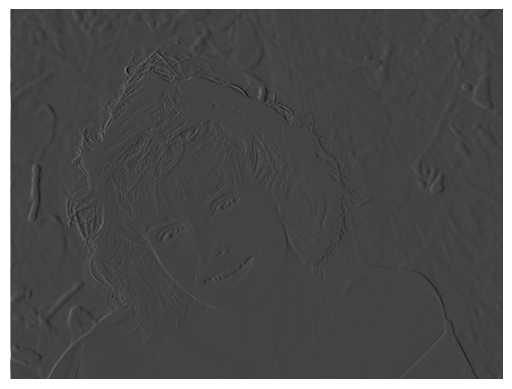

In [6]:
plt.imshow(result, cmap='gray')
plt.axis('off') 
plt.show()

# Diferença de entropia da Imagem Original vs Imagem de Resíduos

In [7]:
# image entropy
def calcEntropy(img):
    hist = cv2.calcHist([img],[0],None,[256],[0,256])
    hist = hist.ravel()/hist.sum()
    logs = np.log2(hist+0.00001)
    entropy = -1 * (hist*logs).sum()

    return entropy

def calcEntropyError(img):
    hist = cv2.calcHist([img],[0],None,[512],[0,512])
    hist = hist.ravel()/hist.sum()
    logs = np.log2(hist+0.00001)
    entropy = -1 * (hist*logs).sum()

    return entropy

In [8]:
print("Entropia da imagem original:", calcEntropy(imagem))

min_val = np.min(result)
shifted = result - min_val

print("Entropia da imagem de resíduos", calcEntropy(shifted.astype(np.uint8)))

Entropia da imagem original: 7.1393776
Entropia da imagem de resíduos 4.018912


# Aplicação da Inversa da Predição

In [9]:
def prediction_decomp(func_inv, residual):
    size = residual.shape
    reconstructed = np.zeros(size, int)
    residual = residual.astype(int)
    
    for y in range(0, size[0]):
        for x in range(0, size[1]):
            reconstructed[y, x] = func_inv(x, y, reconstructed, residual)

    return reconstructed

In [10]:
rebuilt = prediction_decomp(previous_inv, result).astype(np.uint8)

print(np.min(rebuilt), np.max(rebuilt))

80 255


# Imagem reconstruída

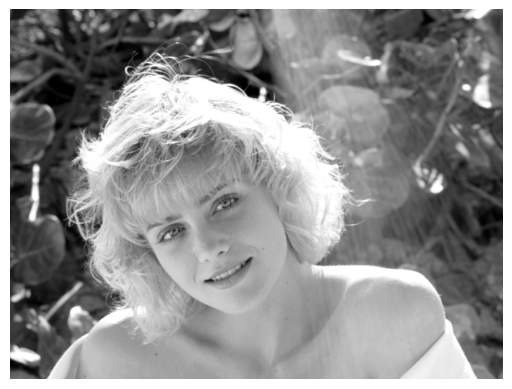

In [11]:
plt.imshow(rebuilt, cmap='gray')
plt.axis('off') 
plt.show()

In [12]:
# Root Mean Square Error
def rmse_metric(img1, img2):
    return np.sqrt(np.mean((img1.astype("float") - img2.astype("float")) ** 2))

rmse = rmse_metric(imagem, rebuilt)
print(f"Erro da reconstrução: {rmse}")

Erro da reconstrução: 0.0
